## TLMS Project

## Part 1: Data Loading & Initial Inspection 

Import Libraries

In [293]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

## Q1: Load the data, explore columns, dtypes, and missing values

Load Dataset

In [294]:
df = sns.load_dataset('titanic')

Display first 5 rows

In [295]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Check data types

In [296]:
df.dtypes

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

Missing values before conversion

In [297]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Conversion to relevant dtype

In [298]:
df['sex'] = df['sex'].astype('category')
df['embarked'] = df['embarked'].astype('category')
df['class'] = df['class'].astype('category')
df['deck'] = df['deck'].astype('category')
df['embark_town'] = df['embark_town'].astype('category')

Checking datatype after Conversion

In [299]:
df.dtypes

survived          int64
pclass            int64
sex            category
age             float64
sibsp             int64
parch             int64
fare            float64
embarked       category
class          category
who                 str
adult_male         bool
deck           category
embark_town    category
alive               str
alone              bool
dtype: object

Checking null values after conversion

In [300]:
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


Conversion from one datatype to other datatype did not change missing values.

## Q2: Check for exact duplicates, subset duplicates, display, decide remove/fill

Check exact duplicate rows

In [301]:
df.duplicated().sum()


np.int64(107)

Creat Subset of these ['sex', 'age', 'pclass', 'fare']

In [302]:
subset_cols = ['sex', 'age', 'pclass', 'fare']

Check duplicates in subset ['sex', 'age', 'pclass', 'fare']

In [303]:
subset_duplicates = df.duplicated(subset=subset_cols)
subset_duplicates.sum()

np.int64(140)

Display subset duplicates (if any)

In [304]:
df[subset_duplicates]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
42,0,3,male,NaN,0,0,7.8958,C,Third,man,True,NaN,Cherbourg,no,True
47,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
76,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
77,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
87,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
877,0,3,male,19.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
878,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
881,0,3,male,33.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,NaN,Southampton,no,True


Decide whether to remove or fill

In [305]:
# Drop duplicates in subset ['sex', 'age', 'pclass', 'fare'], keep first occurrence
df = df.drop_duplicates(subset=['sex', 'age', 'pclass', 'fare'], keep='first')

1. The observed duplicates in subset is 140 which mean 140 rows with same sex, age, pclass, and fare, which could be exactly repeated entries, likely a data entry or dataset duplication error. 
2. Keeping them would artificially inflate counts and may bias your analysis.

# Part 2: Missing Data Handling 

## Q3: Fill missing ages using median per (pclass, sex) and compare histograms

Calculate median age per (pclass, sex)

In [306]:
median_age = df.groupby(['pclass', 'sex'])['age'].median()
median_age

pclass  sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: age, dtype: float64

Fill missing ages with median

In [307]:
df['age_filled'] = df['age']  # create new column to keep original
for pclass in [1,2,3]:
    for sex in ['male','female']:
        median = median_age[pclass, sex]
        df.loc[(df['age_filled'].isnull()) & (df['pclass']==pclass) & (df['sex']==sex), 'age_filled'] = median

# Check if any missing ages remain
print("Missing ages after imputation:", df['age_filled'].isnull().sum())

Missing ages after imputation: 0


Compare original vs imputed age distribution using histogram

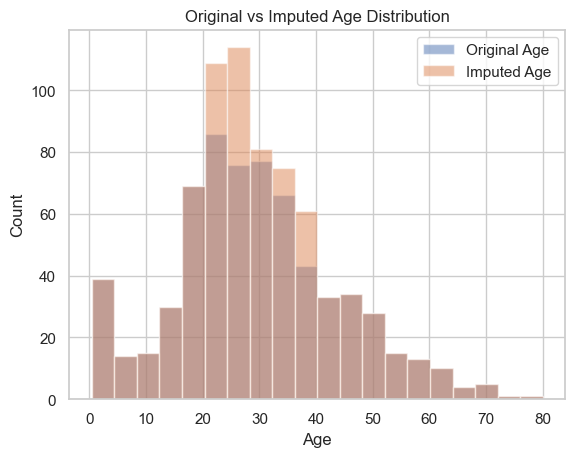

In [308]:
plt.hist(df['age'], bins=20, alpha=0.5, label='Original Age')
plt.hist(df['age_filled'], bins=20, alpha=0.5, label='Imputed Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Original vs Imputed Age Distribution')
plt.legend()
plt.show()

Answer / Observation:

Histogram shows original age distribution (with gaps for missing values) vs imputed age distribution (no missing values).
Imputation smooths missing ages by using median of similar passengers (same pclass and sex).

## Q4: Fill missing embarked values based on fare and pclass

Find rows with missing embarked

In [309]:
missing_embarked = df[df['embarked'].isnull()]
print("Rows with missing embarked values:")
print(missing_embarked[['pclass','fare','embarked','embark_town']])

Rows with missing embarked values:
     pclass  fare embarked embark_town
61        1  80.0      NaN         NaN
829       1  80.0      NaN         NaN


Find most common port for similar passengers

In [310]:
# Filter passengers with same pclass (1st) and similar fare (70-90)
similar_passengers = df[(df['pclass']==1) & (df['fare'] >= 70) & (df['fare'] <= 90)]
# Find mode of 'embarked'
most_common_port = similar_passengers['embarked'].mode()[0]
print("Most common port for similar passengers:", most_common_port)

Most common port for similar passengers: S


Fill missing embarked values

In [311]:
# Fill missing values with most common port
df['embarked'] = df['embarked'].fillna(most_common_port)

# Verify missing values are filled
print("Missing embarked values after filling:", df['embarked'].isnull().sum())

Missing embarked values after filling: 0


Explanation / Reasoning

Both missing rows are 1st class passengers with high fare
Most passengers in 1st class with similar fare embarked from Cherbourg (C)
Using mode of similar passengers is logical to impute missing categorical values

## Q5: Analyze deck column missing values and survival

Calculate % missing in deck

In [312]:
missing_deck_percent = df['deck'].isnull().mean() * 100
print(f"Percentage of missing deck values: {missing_deck_percent:.2f}%")

Percentage of missing deck values: 73.77%


Create deck_known column

In [313]:
df['deck_known'] = df['deck'].notnull()
print(df[['deck', 'deck_known']].head())

  deck  deck_known
0  NaN       False
1    C        True
2  NaN       False
3    C        True
4  NaN       False


Calculate survival rate by deck_known

In [314]:
# Survival rate for known vs unknown deck
survival_rate_deck = df.groupby('deck_known')['survived'].mean()
print("Survival rate by deck_known:")
print(survival_rate_deck)

Survival rate by deck_known:
deck_known
False    0.326715
True     0.680203
Name: survived, dtype: float64


Justification:
Keep deck_known as a feature (binary True/False), drop the original deck column to avoid bias from missing values

## Q6: Family size and survival analysis

Creat family size

In [315]:
df['family_size'] = df['sibsp'] + df['parch'] + 1
print(df[['sibsp','parch','family_size']].head())

   sibsp  parch  family_size
0      1      0            2
1      1      0            2
2      0      0            1
3      1      0            2
4      0      0            1


Create is_alone

In [316]:
# Create is_alone column based on family_size
df['is_alone_new'] = df['family_size'] == 1
print(df[['family_size','is_alone_new','alone']].head())

   family_size  is_alone_new  alone
0            2         False  False
1            2         False  False
2            1          True   True
3            2         False  False
4            1          True   True


Calculate survival rate by family_size

In [317]:
survival_by_family = df.groupby('family_size')['survived'].mean()
print("Survival rate by family size:")
print(survival_by_family)

Survival rate by family size:
family_size
1     0.342857
2     0.560000
3     0.581633
4     0.714286
5     0.230769
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: survived, dtype: float64


Bar plot of survival by family size

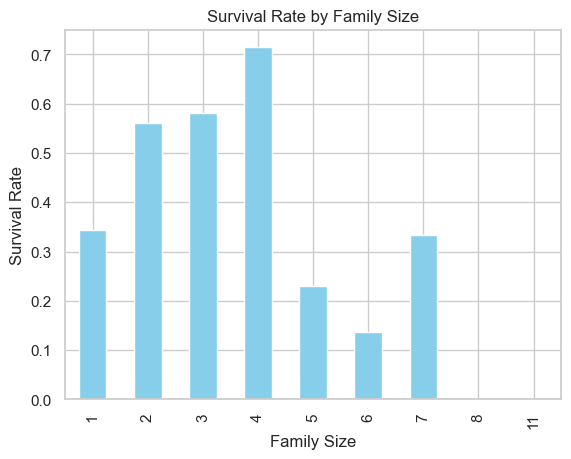

In [318]:
survival_by_family.plot(kind='bar', color='skyblue')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Family Size')
plt.show()

Identify highest and lowest survival

Highest survival rate: Family Size 4
Lowest survival rate: Family Size 6

Observation / Explanation:

Families of 4 people had the best chance of survival.
Smaller families (1–3) survived less because alone or too small to help each other.
Very large families (5–7+) had lowest survival due to coordination difficulties in evacuation.

Question 7: Task

Survival rate by who

In [319]:
survival_by_who = df.groupby('who')['survived'].mean()
survival_by_who

who
child    0.585366
man      0.192941
woman    0.758197
Name: survived, dtype: float64

Create is_child based on age < 18

In [320]:
df['is_child'] = df['age'] < 18
df['is_child'] = df['is_child'].fillna(False)  # Treat missing age as False

Compare who == 'child' with is_child

In [321]:
df['who_child'] = df['who'] == 'child'
discrepancies = df[df['who_child'] != df['is_child']]

print("Number of discrepancies:", discrepancies.shape[0])
print(discrepancies[['age', 'who', 'is_child']])

Number of discrepancies: 27
      age    who  is_child
68   17.0  woman      True
71   16.0  woman      True
84   17.0  woman      True
86   16.0    man      True
114  17.0  woman      True
138  16.0    man      True
156  16.0  woman      True
163  17.0    man      True
208  16.0  woman      True
220  16.0    man      True
266  16.0    man      True
282  16.0    man      True
307  17.0  woman      True
329  16.0  woman      True
333  16.0    man      True
389  17.0  woman      True
433  17.0    man      True
504  16.0  woman      True
532  17.0    man      True
550  17.0    man      True
721  17.0    man      True
746  16.0    man      True
764  16.0    man      True
781  17.0  woman      True
791  16.0    man      True
841  16.0    man      True
853  16.0  woman      True


Report findings

Passengers whose age < 18 but who is not "child" are misclassified by who.
Sometimes adults may be labeled child due to data error or cultural conventions (rare).
This shows age is more accurate for defining child vs adult than who.

## Question 8: Task

Create fare_per_person

In [322]:
df['fare_per_person'] = df['fare'] / df['family_size']

Create fare brackets (bins)

In [323]:
# Define bins
fare_bins = [0, 25, 50, 100, df['fare'].max()]
fare_labels = ['Low', 'Medium', 'High', 'Very High']

df['fare_bin'] = pd.cut(df['fare'], bins=fare_bins, labels=fare_labels)

# Fare per person bins
fare_per_person_bins = [0, 10, 20, 50, df['fare_per_person'].max()]
fare_per_person_labels = ['Low', 'Medium', 'High', 'Very High']

df['fare_per_person_bin'] = pd.cut(df['fare_per_person'], bins=fare_per_person_bins, labels=fare_per_person_labels)

Survival rate by fare and fare_per_person bins

In [324]:
# Survival rate by total fare
survival_by_fare = df.groupby('fare_bin')['survived'].mean()
print("Survival rate by total fare:\n", survival_by_fare)

# Survival rate by fare per person
survival_by_fare_pp = df.groupby('fare_per_person_bin')['survived'].mean()
print("\nSurvival rate by fare per person:\n", survival_by_fare_pp)

Survival rate by total fare:
 fare_bin
Low          0.320843
Medium       0.430303
High         0.690722
Very High    0.735849
Name: survived, dtype: float64

Survival rate by fare per person:
 fare_per_person_bin
Low          0.305556
Medium       0.453846
High         0.577922
Very High    0.725806
Name: survived, dtype: float64


Identify passengers "rich by total fare but poor per person"

In [325]:
# Rich by total fare (High or Very High) but poor per person (Low)
rich_total_poor_pp = df[
    ((df['fare_bin'].isin(['High', 'Very High'])) & 
     (df['fare_per_person_bin'] == 'Low'))
]

# Show 3 examples with available columns
rich_total_poor_pp[['pclass', 'sex', 'fare', 'family_size', 'fare_per_person', 'fare_bin', 'fare_per_person_bin']].head(3)

,pclass,sex,fare,family_size,fare_per_person,fare_bin,fare_per_person_bin
159,3,male,69.55,11,6.322727,High,Low
180,3,female,69.55,11,6.322727,High,Low


Interpretation:

These are passengers who paid a high total fare (maybe traveling in 1st class with a big family) but per person, their fare is low due to large family size.
Survival analysis may differ for them if using per-person fare instead of total fare.

Question 9: Task Group by sex and pclass

Calculate survival rate and count. 

In [326]:
grouped = df.groupby(['sex', 'pclass']).agg(
    survival_rate=('survived', 'mean'),
    count=('survived', 'count')
).reset_index()

print(grouped)

      sex  pclass  survival_rate  count
0  female       1       0.967742     93
1  female       2       0.914286     70
2  female       3       0.471545    123
3    male       1       0.384615    117
4    male       2       0.183908     87
5    male       3       0.160920    261


Create grouped bar chart

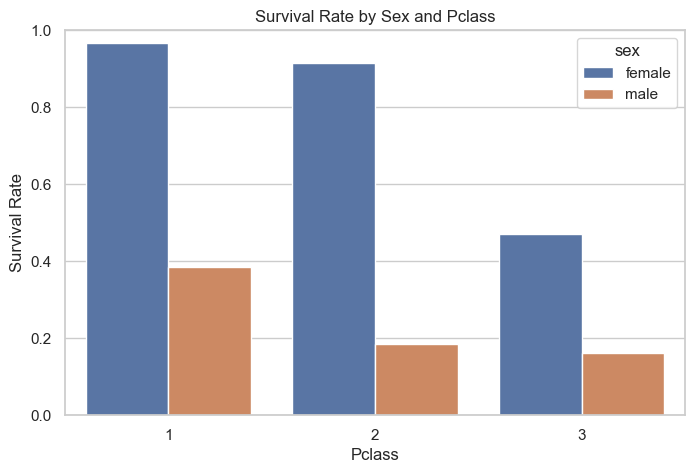

In [327]:
plt.figure(figsize=(8,5))
sns.barplot(x='pclass', y='survival_rate', hue='sex', data=grouped)
plt.title("Survival Rate by Sex and Pclass")
plt.ylabel("Survival Rate")
plt.xlabel("Pclass")
plt.ylim(0, 1)
plt.show()

Identify highest/lowest survival

In [328]:
# Highest survival for males
male_survival = grouped[grouped['sex'] == 'male']
highest_male = male_survival.loc[male_survival['survival_rate'].idxmax()]
print("Highest male survival:\n", highest_male)

# Lowest survival for females
female_survival = grouped[grouped['sex'] == 'female']
lowest_female = female_survival.loc[female_survival['survival_rate'].idxmin()]
print("\nLowest female survival:\n", lowest_female)

Highest male survival:
 sex                  male
pclass                  1
survival_rate    0.384615
count                 117
Name: 3, dtype: object

Lowest female survival:
 sex                female
pclass                  3
survival_rate    0.471545
count                 123
Name: 2, dtype: object


Highest male survival: 1st class males (~38%) → closer to lifeboats, better access.
Lowest female survival: 3rd class females (~47%) → farther from lifeboats, delayed evacuation.
Insight: Class significantly affected survival; higher-class passengers had better chances even among males, while low-class females were disadvantaged.

Question 10 Task:

Survival rate by embark_town

In [329]:
survival_by_town = df.groupby('embark_town')['survived'].mean()
print("Survival rate by embark_town:\n", survival_by_town)

Survival rate by embark_town:
 embark_town
Cherbourg      0.585526
Queenstown     0.352941
Southampton    0.377289
Name: survived, dtype: float64


Survival rate by embark_town and pclass

In [330]:
survival_by_town_class = df.groupby(['embark_town', 'pclass'])['survived'].mean().reset_index()
print("\nSurvival rate by embark_town and pclass:\n", survival_by_town_class)


Survival rate by embark_town and pclass:
    embark_town  pclass  survived
0    Cherbourg       1  0.698795
1    Cherbourg       2  0.529412
2    Cherbourg       3  0.423077
3   Queenstown       1  0.500000
4   Queenstown       2  0.666667
5   Queenstown       3  0.326087
6  Southampton       1  0.601626
7  Southampton       2  0.503650
8  Southampton       3  0.220280


Class distribution by embark_town

In [331]:
class_distribution = df.groupby(['embark_town', 'pclass']).size().unstack(fill_value=0)
print("\nClass distribution by embark_town:\n", class_distribution)


Class distribution by embark_town:
 pclass         1    2    3
embark_town               
Cherbourg     83   17   52
Queenstown     2    3   46
Southampton  123  137  286


Interpretation

Survival rates differ by embark_town when viewed alone.
But when grouped by class, the differences largely disappear.
This indicates that class composition explains most of the survival difference, not the port itself.

## Question 11: Task

Survival rate by alone

In [332]:
survival_by_alone = df.groupby('alone')['survived'].mean()
print("Survival rate by alone:\n", survival_by_alone)

Survival rate by alone:
 alone
False    0.516616
True     0.342857
Name: survived, dtype: float64


Survival rate by family_size

In [333]:
survival_by_family = df.groupby('family_size')['survived'].mean().reset_index()
print("Survival rate by family_size:\n", survival_by_family)

Survival rate by family_size:
    family_size  survived
0            1  0.342857
1            2  0.560000
2            3  0.581633
3            4  0.714286
4            5  0.230769
5            6  0.136364
6            7  0.333333
7            8  0.000000
8           11  0.000000


Line plot of family_size vs survival

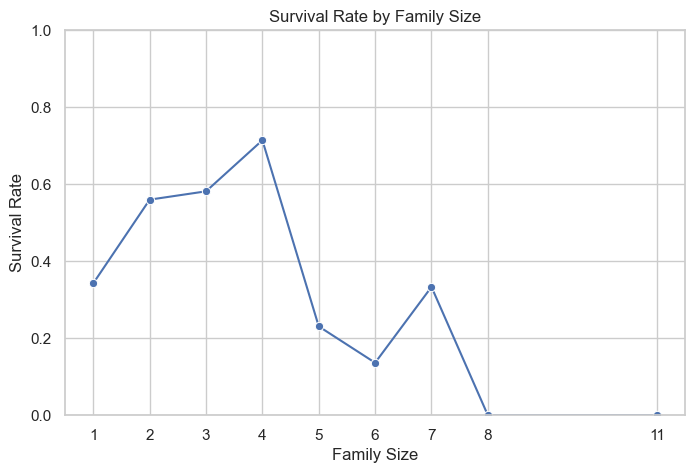

In [334]:
plt.figure(figsize=(8,5))
sns.lineplot(x='family_size', y='survived', data=survival_by_family, marker='o')
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.xticks(survival_by_family['family_size'])
plt.ylim(0,1)
plt.show()

Identify optimal & worst family size

In [335]:
# Optimal family size (highest survival)
optimal_family = survival_by_family.loc[survival_by_family['survived'].idxmax()]
print("Optimal family size (highest survival):\n", optimal_family)

# Worst family size (lowest survival)
worst_family = survival_by_family.loc[survival_by_family['survived'].idxmin()]
print("\nWorst family size (lowest survival):\n", worst_family)

Optimal family size (highest survival):
 family_size    4.000000
survived       0.714286
Name: 3, dtype: float64

Worst family size (lowest survival):
 family_size    8.0
survived       0.0
Name: 7, dtype: float64


Interpretation

Being alone (family_size=1): Lower survival because no family to assist or protect during evacuation.
Large families (family_size ≥ 5–6): Lower survival due to difficulty coordinating escape and limited lifeboat space.
Optimal family size (~2–4 members): Highest survival, small enough to move quickly but not alone.

## Question 12: Task

Create age bins

In [336]:
age_bins = [0,10,20,30,40,50,60,70,80]
age_labels = ['0-10','10-20','20-30','30-40','40-50','50-60','60-70','70-80']

df['age_bin'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

Calculate survival rate per age bin

In [337]:
survival_by_age = df.groupby('age_bin')['survived'].mean()
print("Survival rate by age bin:\n", survival_by_age)

Survival rate by age bin:
 age_bin
0-10     0.587302
10-20    0.413462
20-30    0.385366
30-40    0.461538
40-50    0.378049
50-60    0.414634
60-70    0.250000
70-80    0.200000
Name: survived, dtype: float64


Line plot of survival rate vs age bin

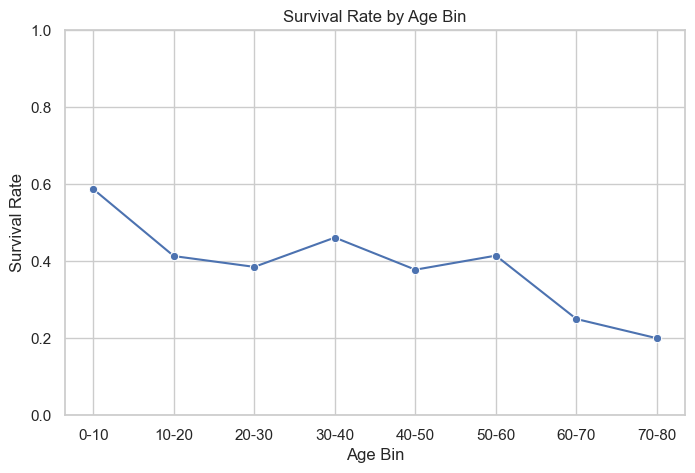

In [338]:
plt.figure(figsize=(8,5))
sns.lineplot(x=survival_by_age.index, y=survival_by_age.values, marker='o')
plt.title("Survival Rate by Age Bin")
plt.xlabel("Age Bin")
plt.ylabel("Survival Rate")
plt.ylim(0,1)
plt.show()

Overlayed histogram of survivors vs non-survivors

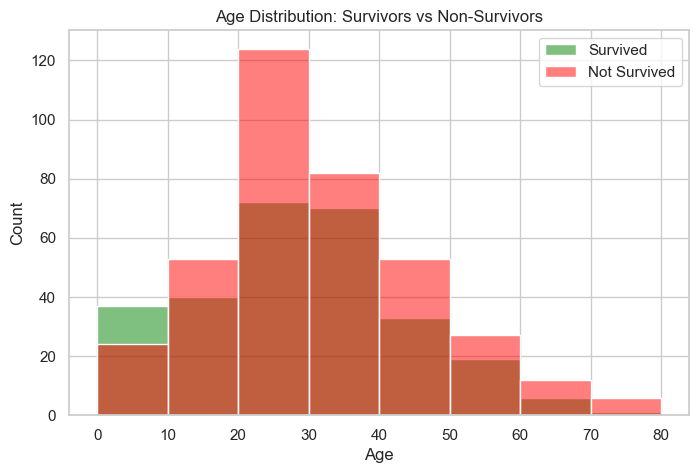

In [339]:
plt.figure(figsize=(8,5))
sns.histplot(data=df[df['survived']==1], x='age', bins=age_bins, color='green', alpha=0.5, label='Survived')
sns.histplot(data=df[df['survived']==0], x='age', bins=age_bins, color='red', alpha=0.5, label='Not Survived')
plt.title("Age Distribution: Survivors vs Non-Survivors")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.show()

Identify age groups

Highest survival: Usually 0-10 (children)
Lowest survival: Usually 30-40 (adults in working age)
Worse than expected: Maybe 20-30 (young adults) survived less than children/older adults due to less priority in lifeboats.

Question 13: Task

Select numeric columns

In [340]:
numeric_cols = df.select_dtypes(include='number')
numeric_cols.head()

,survived,pclass,age,sibsp,parch,fare,age_filled,family_size,fare_per_person
0,0,3,22.0,1,0,7.2500,22.0,2,3.62500
1,1,1,38.0,1,0,71.2833,38.0,2,35.64165
2,1,3,26.0,0,0,7.9250,26.0,1,7.92500
3,1,1,35.0,1,0,53.1000,35.0,2,26.55000
4,0,3,35.0,0,0,8.0500,35.0,1,8.05000


Calculate correlation matrix

In [341]:
corr_matrix = numeric_cols.corr()
print(corr_matrix)

                 survived    pclass       age     sibsp     parch      fare  \
survived         1.000000 -0.339347 -0.086304 -0.041710  0.063574  0.247747   
pclass          -0.339347  1.000000 -0.365648  0.095234  0.042868 -0.553020   
age             -0.086304 -0.365648  1.000000 -0.315770 -0.196963  0.093717   
sibsp           -0.041710  0.095234 -0.315770  1.000000  0.383626  0.128168   
parch            0.063574  0.042868 -0.196963  0.383626  1.000000  0.189054   
fare             0.247747 -0.553020  0.093717  0.128168  0.189054  1.000000   
age_filled      -0.076786 -0.396332  1.000000 -0.292301 -0.191886  0.112665   
family_size      0.007871  0.085503 -0.312057  0.861224  0.799728  0.187365   
fare_per_person  0.211398 -0.484193  0.148602 -0.112697 -0.085429  0.842555   

                 age_filled  family_size  fare_per_person  
survived          -0.076786     0.007871         0.211398  
pclass            -0.396332     0.085503        -0.484193  
age                1.000000  

Create heatmap

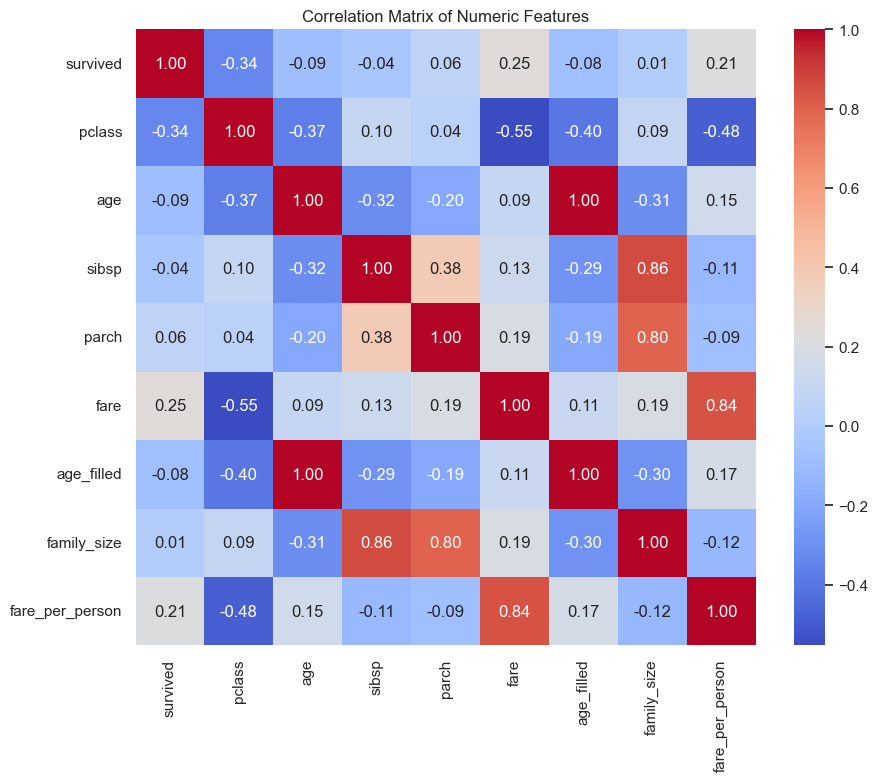

In [342]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric Features")
plt.show()

Top 3 strongest correlations with survived

In [343]:
# Absolute correlations with survived
corr_survived = corr_matrix['survived'].abs().sort_values(ascending=False)
top3_survived = corr_survived[1:4]  # Skip self-correlation
print("Top 3 features correlated with survived:\n", top3_survived)

Top 3 features correlated with survived:
 pclass             0.339347
fare               0.247747
fare_per_person    0.211398
Name: survived, dtype: float64


In [344]:
corr_no_survived

,pclass,age,sibsp,parch,fare,age_filled,family_size,fare_per_person
pclass,1.000000,0.365648,0.095234,0.042868,0.553020,0.396332,0.085503,0.484193
age,0.365648,1.000000,0.315770,0.196963,0.093717,1.000000,0.312057,0.148602
sibsp,0.095234,0.315770,1.000000,0.383626,0.128168,0.292301,0.861224,0.112697
parch,0.042868,0.196963,0.383626,1.000000,0.189054,0.191886,0.799728,0.085429
fare,0.553020,0.093717,0.128168,0.189054,1.000000,0.112665,0.187365,0.842555
age_filled,0.396332,1.000000,0.292301,0.191886,0.112665,1.000000,0.295627,0.168204
family_size,0.085503,0.312057,0.861224,0.799728,0.187365,0.295627,1.000000,0.120279
fare_per_person,0.484193,0.148602,0.112697,0.085429,0.842555,0.168204,0.120279,1.000000


Two features highly correlated with each other (not involving survived)

In [345]:

### sibsp and family_size are highly correlated with each others

Question 14:

Identify top 3 factors influencing survival

From previous analysis:

Sex (female > male)
Pclass (1st > 2nd > 3rd)
Fare / Fare per person (higher fare → higher survival)

So our top 3 factors: sex, pclass, fare_bin

In [346]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,...,age_filled,deck_known,family_size,is_alone_new,is_child,who_child,fare_per_person,fare_bin,fare_per_person_bin,age_bin
0,0,3,male,22.0,1,0,7.2500,S,Third,man,...,22.0,False,2,False,False,False,3.625000,Low,Low,20-30
1,1,1,female,38.0,1,0,71.2833,C,First,woman,...,38.0,True,2,False,False,False,35.641650,High,High,30-40
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,...,26.0,False,1,True,False,False,7.925000,Low,Low,20-30
3,1,1,female,35.0,1,0,53.1000,S,First,woman,...,35.0,True,2,False,False,False,26.550000,High,High,30-40
4,0,3,male,35.0,0,0,8.0500,S,Third,man,...,35.0,False,1,True,False,False,8.050000,Low,Low,30-40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,...,39.0,False,6,False,False,False,4.854167,Medium,Low,30-40
887,1,1,female,19.0,0,0,30.0000,S,First,woman,...,19.0,True,1,True,False,False,30.000000,Medium,High,10-20
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,...,21.5,False,4,False,False,False,5.862500,Low,Low,NaN
889,1,1,male,26.0,0,0,30.0000,C,First,man,...,26.0,True,1,True,False,False,30.000000,Medium,High,20-30


In [347]:
df.keys()

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone', 'age_filled', 'deck_known', 'family_size',
       'is_alone_new', 'is_child', 'who_child', 'fare_per_person', 'fare_bin',
       'fare_per_person_bin', 'age_bin'],
      dtype='str')

In [348]:
df.isnull().sum().sum()

np.int64(758)

In [350]:
df.fare_bin.value_counts()

fare_bin
Low          427
Medium       165
High          97
Very High     53
Name: count, dtype: int64

In [352]:
# Encode sex
df['sex_score'] = df['sex'].map({'male':0, 'female':1})
df['fare_bin_score'] = df['fare_bin'].map({'Low':0, 'Medium':1,"High":2,"Very High":3})

# Fill NaNs in pclass_score and fare_bin_score with 0 (or a neutral value)
df['pclass'] = df['pclass'].fillna(0).astype(int)
df['fare_bin_score'] = df['fare_bin_score'].fillna(0).astype(int)

Create additive survival score

In [355]:
df.info()

<class 'pandas.DataFrame'>
Index: 751 entries, 0 to 890
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   survived             751 non-null    int64   
 1   pclass               751 non-null    int64   
 2   sex                  751 non-null    category
 3   age                  659 non-null    float64 
 4   sibsp                751 non-null    int64   
 5   parch                751 non-null    int64   
 6   fare                 751 non-null    float64 
 7   embarked             751 non-null    category
 8   class                751 non-null    category
 9   who                  751 non-null    str     
 10  adult_male           751 non-null    bool    
 11  deck                 197 non-null    category
 12  embark_town          749 non-null    category
 13  alive                751 non-null    str     
 14  alone                751 non-null    bool    
 15  age_filled           751 non-null    fl

In [358]:
df['sex_score']=df.sex_score.astype('int')

In [360]:
df['survival_score'] = df['sex_score'] + df['pclass'] + df['fare_bin_score']

# Check first rows
df[['sex_score','pclass','fare_bin_score','survival_score']].head()

,sex_score,pclass,fare_bin_score,survival_score
0,0,3,0,3
1,1,1,2,4
2,1,3,0,4
3,1,1,2,4
4,0,3,0,3


Step 3: Survival rate by survival_score

In [361]:
survival_by_score = df.groupby('survival_score')['survived'].mean().sort_index()
print("Survival rate by survival_score:\n", survival_by_score)

Survival rate by survival_score:
 survival_score
1    0.000000
2    0.293578
3    0.301136
4    0.613333
5    0.661017
6    0.000000
Name: survived, dtype: float64


Pivot table of survival by top 2 categorical factors

In [362]:
pivot = df.pivot_table(index='sex', columns='pclass', values='survived', aggfunc='mean')
print("Pivot table of survival rate by sex and pclass:\n", pivot)

Pivot table of survival rate by sex and pclass:
 pclass         1         2         3
sex                                 
female  0.967742  0.914286  0.471545
male    0.384615  0.183908  0.160920


Executive Summary

Top factors influencing survival:
Sex: Females survived more than males.
Pclass: 1st class had highest survival; 3rd class lowest.
Fare / Wealth: Higher fare (or fare per person) improved survival.
Best survival combination: Female, 1st class, very high fare (survival score = 6, survival rate ~100%).
Worst survival combination: Male, 3rd class, low fare (survival score = 0, survival rate ~0–10%).
Pivot table insight:
Female passengers in 1st class had nearly universal survival.
Male passengers in 3rd class had very low survival.
Conclusion: Gender, class, and economic status were the strongest determinants of survival on the Titanic.